### ASTR 3300/5300: Astrostatistics
***N. Pol***
___

# Homework 3
### Due: Wednesday, Sep. 30 at 11.59pm CST
---

## Only one problem this week

This problem uses a dataset in `/coursework/homeworks/hw_data/`.

1) Read in `hw3_data_1.npy`. This is a (50 x 2) numpy array, with measurements in the first column and uncertainties in the second column. Using the analytic results for heteroscedastic Gaussian data from lectures, compute the sample mean and the standard error on the sample mean from for this data.

2) Reusing some approaches and tools from `Lecture_6`, write a ln-likelihood function for heteroscedastic Gaussian data, and use it in a fitting algorithm to find the best-fit mean. *Remember that scipy optimizers are set up to minimize functions.*

3) Using the same numerical technique from `Lecture_5`, compute the Fisher uncertainty estimate on the mean.

4) Using the bootstrap method, generate $1000$ bootstrap realizations of this dataset. *DO NOT use the `astroML` code. Write your own bootstrap function from scratch. Also recall that when resampling data, measurements and uncertainties should stay paired together.*

5) Repeat (2) with all $1000$ boostrap datasets to find the distribution of the sample mean. Plot a normalized histogram of these bootstrap means, and overplot a Gaussian pdf with the mean and std found in (1). Do these agree?

6) While we have fitted a heteroscedastic Gaussian to this data, let's try something else. Write some code to define a ln-likelihood for a Laplace distribution evaluated on this data. Fit simultaneously for the Laplace location parameter $\mu$ and scale parameter $\Delta$.

7) Compute the AIC values for the heteroscedastic Gaussian model and the Laplacian model. Which model is favored by the data?

8) Using the $1000$ bootstrap datasets from before, fit for the Laplacian $\mu$ and $\Delta$ for each. Make a nice `corner` plot of the distributions of $\mu$ and $\Delta$ that shows both the marginal $1$D distributions and the joint $2$D distribution. Make sure the plot has labels, shows the titles on each $1$D marginal panel, and has $68\%$ and $95\%$ levels.

9) Let's finish with a Fisher uncertainty estimate of the Laplacian parameters. Use the following code to install `numdifftools` which provides a simple way to compute derivatives. We can then compute the Hessian matrix, which is the matrix of the second derivatives of the user's function. This should be computed at the best-fit Laplacian parameters $\mu$ and $\Delta$. To finish, invert the matrix, and then take the square root. The diagonal entries will then be the Fisher uncertainties on $\mu$ and $\Delta$. How does these compare to the bootstrap distribution widths found in (8)?

In [81]:
!pip install numdifftools

In [82]:
import numdifftools as nd
H = nd.Hessian(f_lnlaplace)([beta_laplace[0], beta_laplace[1]])
sigma_laplace = np.linalg.inv(H)**0.5

C:\Users\sydne\AppData\Local\Temp\ipykernel_23960\1206678426.py:3: RuntimeWarning: invalid value encountered in sqrt
  sigma_laplace = np.linalg.inv(H)**0.5


### Solution

# Part 1

In [26]:
import numpy as np
from scipy import stats

In [27]:
#reading in data
data = np.load('hw_data/hw3_data_1.npy')

In [28]:
#sample mean
meas = data[:, 0]
uncer = data[:, 1]
#MLE applied to heteroscedastic gaussian
mu_hat = np.sum(meas / uncer**2) / np.sum(1 / uncer**2)
sigma_mu = np.sum(1 / uncer**2) ** (-0.5)
print('sample mean:', mu_hat)
print('standard error on the mean:', sigma_mu)

sample mean: 3.9179920346060557
standard error on the mean: 0.09481084100510954


# Part 2

In [29]:
#ln likelihood
def lnL(mu, meas, uncer):
    return np.sum(-0.5 * np.log(2 * np.pi * uncer**2) - (meas - mu)**2 / (2 * uncer**2), -1)

In [30]:
#lambda function
f_lnL = lambda beta: -lnL(beta[0], meas=meas, uncer=uncer)

In [31]:
# compute the maximum likelihood (from lecture 6)
from scipy import optimize
beta0 = (np.mean(meas)) 
beta_lnL = optimize.fmin(f_lnL, beta0)
print('best fit mean:', beta_lnL[0])

Optimization terminated successfully.
         Current function value: 147.257863
         Iterations: 12
         Function evaluations: 24
best fit mean: 3.9180328113043634


# Part 3

In [32]:
#grid centered on best fit mean
xgrid = np.linspace(mu_hat -1, mu_hat + 1, 201)

In [33]:
#likelihood on the grid
lnL_grid = np.array([lnL(mu, meas, uncer) for mu in xgrid])
L = np.exp(lnL_grid - lnL_grid.max())

In [34]:
#from lecture 5
sigma_mu = np.diff(np.log(L), n=2)
sigma_mu /= (xgrid[1]-xgrid[0])**2
sigma_mu *= -1
sigma_mu = 1/np.sqrt(sigma_mu)[0]

print("Fisher matrix error on estimated mean is %.3f" % sigma_mu)

Fisher matrix error on estimated mean is 0.095


# Part 4

In [39]:
N = data.shape[0]
n_boot = 1000
rng = np.random.default_rng(42)
#bootstrap function
def bootstrap(data, n_boot, rng):
    indices = rng.integers(0, N, size=(n_boot, N))
    return data[indices]

In [41]:
bootstrap_data = bootstrap(data, n_boot, rng)
x_b = bootstrap_data[:, :, 0]
w_b = 1 / bootstrap_data[:, :, 1]**2
mu_boot = np.sum(w_b * x_b, axis=1) / np.sum(w_b, axis=1)
print('bootstrap mean of means:', np.mean(mu_boot))
print('bootstrap uncertainty on mean:', np.std(mu_boot, ddof=1))

bootstrap mean of means: 3.9196835578561364
bootstrap uncertainty on mean: 0.09457112820145869


# Part 5

In [42]:
#repeat part 2 to find distribution of sample mean
mu_fit = np.empty(n_boot)
for i in range(n_boot):
    meas_b = bootstrap_data[i, :, 0]
    uncer_b = bootstrap_data[i, :, 1]
    f_lnL = lambda beta: -lnL(beta[0], meas=meas_b, uncer=uncer_b)
    mu_fit[i] = optimize.fmin(f_lnL, (np.mean(meas_b)), disp=False)[0]
print('bootstrap mean:', np.mean(mu_fit))
print('bootstrap std:', np.std(mu_fit, ddof=1))

bootstrap mean: 3.919683801914347
bootstrap std: 0.09457056197778572


(array([ 3.,  0.,  2.,  3.,  3.,  6.,  9., 13., 23., 30., 46., 58., 56.,
        82., 82., 95., 78., 79., 67., 53., 77., 38., 29., 29., 13., 15.,
         3.,  4.,  3.,  1.]),
 array([3.59397202, 3.61433589, 3.63469976, 3.65506363, 3.6754275 ,
        3.69579137, 3.71615525, 3.73651912, 3.75688299, 3.77724686,
        3.79761073, 3.8179746 , 3.83833848, 3.85870235, 3.87906622,
        3.89943009, 3.91979396, 3.94015783, 3.96052171, 3.98088558,
        4.00124945, 4.02161332, 4.04197719, 4.06234106, 4.08270493,
        4.10306881, 4.12343268, 4.14379655, 4.16416042, 4.18452429,
        4.20488816]),
 [<matplotlib.patches.Polygon at 0x22f65fea490>])

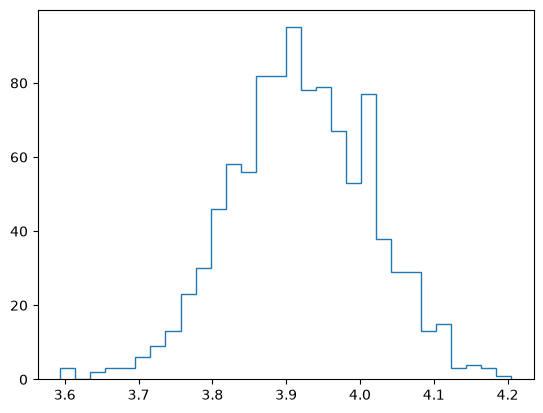

In [47]:
import matplotlib.pyplot as plt
#plot normalized histogram of bootstrap means
plt.hist(mu_fit, histtype='step', bins=30)

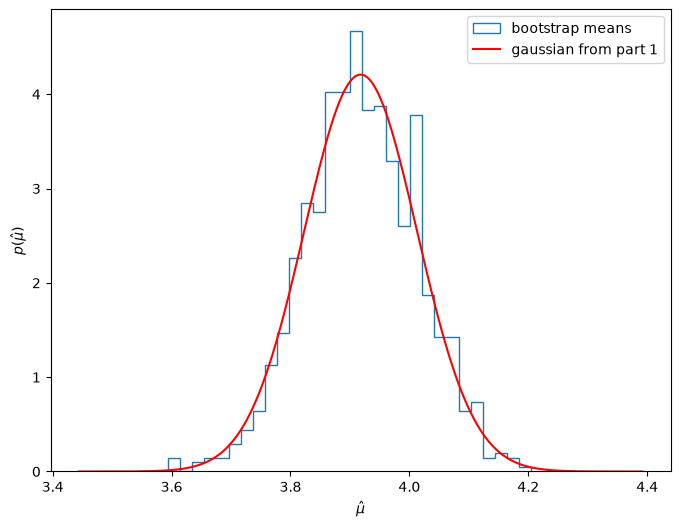

In [56]:
#overplot gaussian pdf with mean and std found in part 1
from scipy.stats import norm
new_xgrid = np.linspace(mu_hat - 5 * sigma_mu, mu_hat + 5 * sigma_mu, 1000)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(mu_fit, bins=30, density=True, histtype='step', label='bootstrap means')
ax.plot(new_xgrid, norm(mu_hat, sigma_mu).pdf(new_xgrid), color='red',
        label=r'gaussian from part 1')
ax.set_xlabel(r'$\hat\mu$')
ax.set_ylabel(r'$p(\hat\mu)$')
ax.legend()
plt.show()

In [89]:
print('these agree fairly well')

these agree fairly well


# Part 6

In [73]:
#laplace function
def lnL_laplace(mu, delta, meas):
    return np.sum(-np.log(2 * delta) - np.abs(meas - mu) / delta, -1)
#negative laplace function
def f_lnlaplace(beta):
    mu, delta = beta
    if delta <= 0:
        return np.inf
    return -lnL_laplace(mu, delta, meas)

In [74]:
f_neg_lnL_laplace = lambda beta: neg_lnL_laplace(beta, meas)

In [75]:
# simultaneous fit for mu and Delta
beta0 = (np.mean(meas), np.std(meas))  
beta_laplace = optimize.fmin(f_neg_lnL_laplace, beta0)

mu_laplace, delta_laplace = beta_laplace
print('laplace location mu:', mu_laplace)
print('laplace scale Delta:', delta_laplace)

Optimization terminated successfully.
         Current function value: 156.788916
         Iterations: 48
         Function evaluations: 90
laplace location mu: 4.085320854743598
laplace scale Delta: 0.8822692326885917


# Part 7

In [76]:
#max lnL at best fit
lnL_gauss_max = lnL(mu_hat, meas, uncer)
lnL_laplace_max = lnL_laplace(mu_laplace, delta_laplace, meas)

In [77]:
#AIC values
AIC_gauss = 2 * 1 - 2 * lnL_gauss_max
AIC_laplace = 2 * 2 - 2 * lnL_laplace_max
print('AIC gaussian:', AIC_gauss)
print('AIC laplace:', AIC_laplace)
print('favored model: gaussian, with lower AIC')

AIC gaussian: 296.5157257746175
AIC laplace: 317.5778323531801
favored model: gaussian, with lower AIC


# Part 8

In [78]:
#fit for the laplacian and delta using bootstraps
laplace_fits = np.empty((n_boot, 2))
for i in range(n_boot):
    meas_b = bootstrap_data[i, :, 0]
    f_neg_lnL = lambda beta: neg_lnL_laplace(beta, meas_b)
    beta0 = (np.mean(meas_b), np.std(meas_b))
    laplace_fits[i] = optimize.fmin(f_neg_lnL, beta0, disp=False)

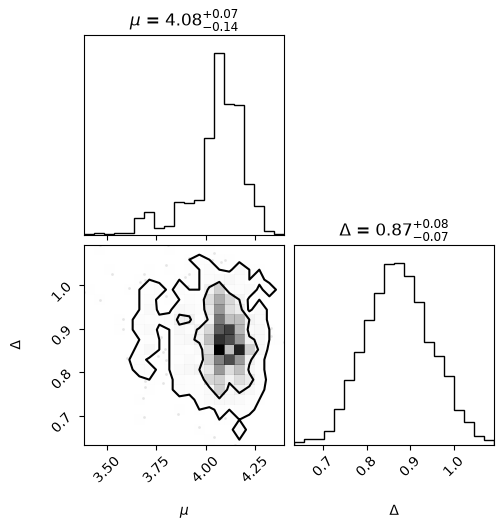

In [79]:
import corner
#corner plot
fig = corner.corner(laplace_fits, labels=[r'$\mu$', r'$\Delta$'], show_titles=True, levels=(0.68, 0.95))
plt.show()

# Part 9

In [83]:
#from earlier in the notebook
H = nd.Hessian(f_lnlaplace)([beta_laplace[0], beta_laplace[1]])
sigma_laplace = np.linalg.inv(H)**0.5

C:\Users\sydne\AppData\Local\Temp\ipykernel_23960\3628469247.py:3: RuntimeWarning: invalid value encountered in sqrt
  sigma_laplace = np.linalg.inv(H)**0.5


In [86]:
#invert the matrix and take square root
invert = np.linalg.inv(H)
sigma_laplace = np.sqrt(np.diag(invert))
#bootstrap stds
sigma_boot = np.std(laplace_fits, axis=0, ddof=1)

In [87]:
print('Fisher:', sigma_laplace)
print('bootstrap:', sigma_boot)

Fisher: [0.10922511 0.08822698]
bootstrap: [0.14004505 0.07508958]


In [88]:
print('comparison: values are very close to each other')

comparison: values are very close to each other


<span style="color:green">NP: correct! </span>